# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3605s 21us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

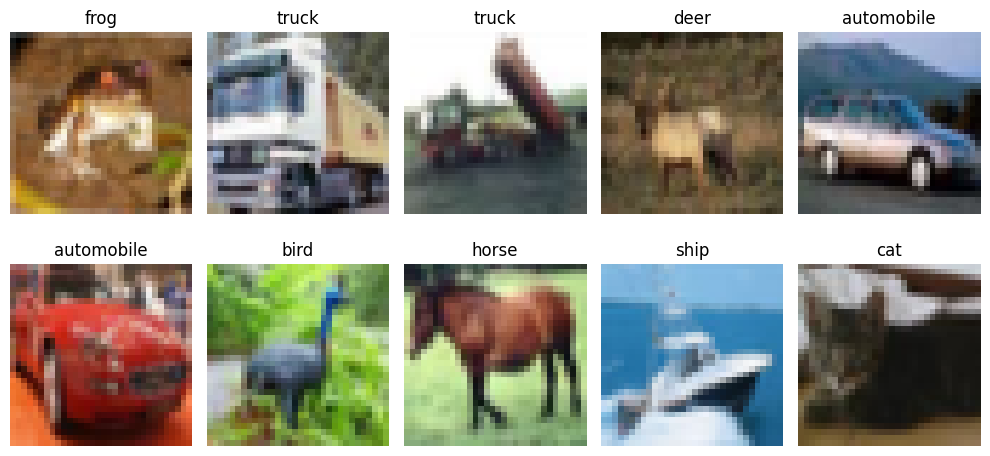

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.2724 - loss: 1.9879 - val_accuracy: 0.3284 - val_loss: 1.8563
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3197 - loss: 1.8603 - val_accuracy: 0.3490 - val_loss: 1.7982
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3387 - loss: 1.8064 - val_accuracy: 0.3798 - val_loss: 1.7525
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3553 - loss: 1.7648 - val_accuracy: 0.4078 - val_loss: 1.7201
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3638 - loss: 1.7412 - val_accuracy: 0.3924 - val_loss: 1.6934
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3754 - loss: 1.7161 - val_accuracy: 0.4130 - val_loss: 1.6735
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3796 - loss: 1.6999 - val_accuracy: 0.4280 - val_loss: 1.6469
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3844 - loss: 1.6870 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4217 - loss: 1.6425
ANN Test Accuracy: 0.42170000076293945


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 128ms/step - accuracy: 0.4696 - loss: 1.4923 - val_accuracy: 0.5330 - val_loss: 1.3378
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 122ms/step - accuracy: 0.6074 - loss: 1.1220 - val_accuracy: 0.5260 - val_loss: 1.3470
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 128ms/step - accuracy: 0.6710 - loss: 0.9453 - val_accuracy: 0.6308 - val_loss: 1.0628
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.7065 - loss: 0.8381 - val_accuracy: 0.5102 - val_loss: 1.7784
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.7393 - loss: 0.7491 - val_accuracy: 0.7060 - val_loss: 0.8540
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7658 - loss: 0.6688 - val_accuracy: 0.7328 - val_loss: 0.8063
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 128ms/step - accuracy: 0.7877 - loss: 0.6014 - val_accuracy: 0.6826 - val_loss: 0.9679
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.8086 - loss

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7285 - loss: 0.8876
CNN Test Accuracy: 0.7285000085830688


## 📈 Compare Learning Curves

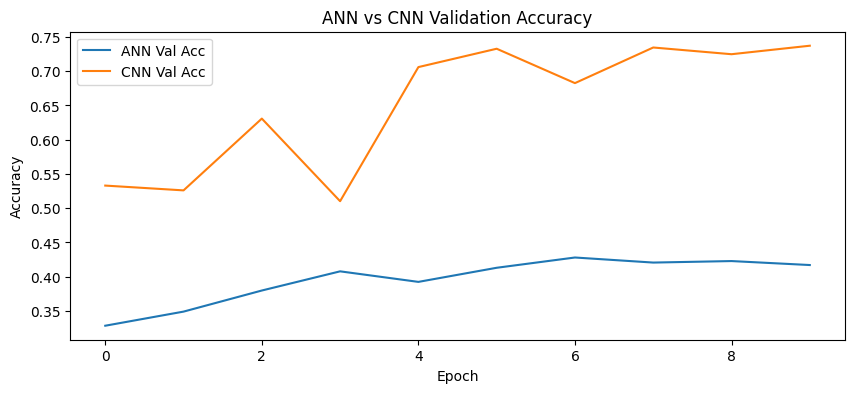

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4217
1,CNN,0.7285


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

In [3]:
# =========================================================
# COMPLETING ALL 5 STUDENT LEARNING TASKS
# =========================================================
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# STEP A: LOAD & PREPARE DATA (So it never crashes!)
# ---------------------------------------------------------
print("Downloading and preparing data...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize images
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# Flatten images for the ANN
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# Task 4: Add EarlyStopping
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

# ---------------------------------------------------------
# Task 1 & 3: Increase ANN layers and train for 20 epochs
# ---------------------------------------------------------
print("\n--- Training Advanced ANN (More Layers, 20 Epochs, EarlyStopping) ---")
adv_ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
adv_ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

adv_ann_history = adv_ann_model.fit(x_train_flat, y_train, epochs=20,
                                    validation_split=0.1, batch_size=64,
                                    callbacks=[early_stopping], verbose=1)
_, adv_ann_test_acc = adv_ann_model.evaluate(x_test_flat, y_test, verbose=0)

# ---------------------------------------------------------
# Task 2, 3, & 4: Change CNN filters (32->64->128), 20 epochs
# ---------------------------------------------------------
print("\n--- Training Advanced CNN (32->64->128 Filters, 20 Epochs, EarlyStopping) ---")
adv_cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
adv_cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

adv_cnn_history = adv_cnn_model.fit(x_train_norm, y_train, epochs=20,
                                    validation_split=0.1, batch_size=64,
                                    callbacks=[early_stopping], verbose=1)
_, adv_cnn_test_acc = adv_cnn_model.evaluate(x_test_norm, y_test, verbose=0)

# ---------------------------------------------------------
# Task 5: Add data augmentation training
# ---------------------------------------------------------
print("\n--- Training Data-Augmented CNN ---")
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    data_augmentation,
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
aug_cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=20,
                                validation_split=0.1, batch_size=64,
                                callbacks=[early_stopping], verbose=1)
_, aug_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)


# ---------------------------------------------------------
# Final Output Comparison Table
# ---------------------------------------------------------
comparison = pd.DataFrame({
    "Model Variant": [
        "1. Advanced ANN (Deep Layout + ES)",
        "2. Advanced CNN (Scaled Filters + 20 Epochs + ES)",
        "3. Data-Augmented CNN (Full Pipeline)"
    ],
    "Test Accuracy": [
        f"{adv_ann_test_acc:.4f}",
        f"{adv_cnn_test_acc:.4f}",
        f"{aug_cnn_test_acc:.4f}"
    ]
})

print("\n=======================================================")
print(" FINAL MODEL COMPARISON (STUDENT TASKS) ")
print("=======================================================")
print(comparison.to_string(index=False))
print("=======================================================")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4215s 25us/step

--- Training Advanced ANN (More Layers, 20 Epochs, EarlyStopping) ---
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 70ms/step - accuracy: 0.2462 - loss: 2.0320 - val_accuracy: 0.3122 - val_loss: 1.9034
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 68ms/step - accuracy: 0.3088 - loss: 1.8812 - val_accuracy: 0.3438 - val_loss: 1.8193
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.3263 - loss: 1.8359 - val_accuracy: 0.3756 - val_loss: 1.7582
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 66ms/step - accuracy: 0.3398 - loss: 1.8048 - val_accuracy: 0.3714 - val_loss: 1.7704
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3475 - loss: 1.7802 - val_accuracy: 0.3842 - val_loss: 1.7219
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.3600 - loss: 1.7552 - val_accuracy: 0.3864 - val_loss: 1.7271
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3647 - loss: 1.7325 - va